1.Before Preprocessing:

   Age Sex ChestPainType  RestingBP  Cholesterol  FastingBS RestingECG  MaxHR  \
0   40   M           ATA        140          289          0     Normal    172   
1   49   F           NAP        160          180          0     Normal    156   
2   37   M           ATA        130          283          0         ST     98   
3   48   F           ASY        138          214          0     Normal    108   
4   54   M           NAP        150          195          0     Normal    122   

  ExerciseAngina  Oldpeak ST_Slope  HeartDisease  
0              N      0.0       Up             0  
1              N      1.0     Flat             1  
2              N      0.0       Up             0  
3              Y      1.5     Flat             1  
4              N      0.0       Up             0  


2.Visualization:



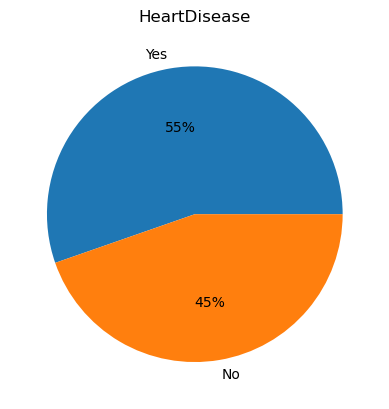

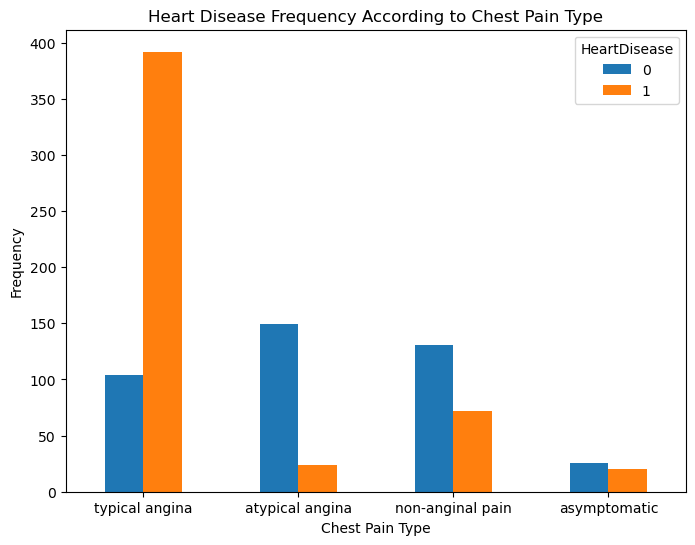

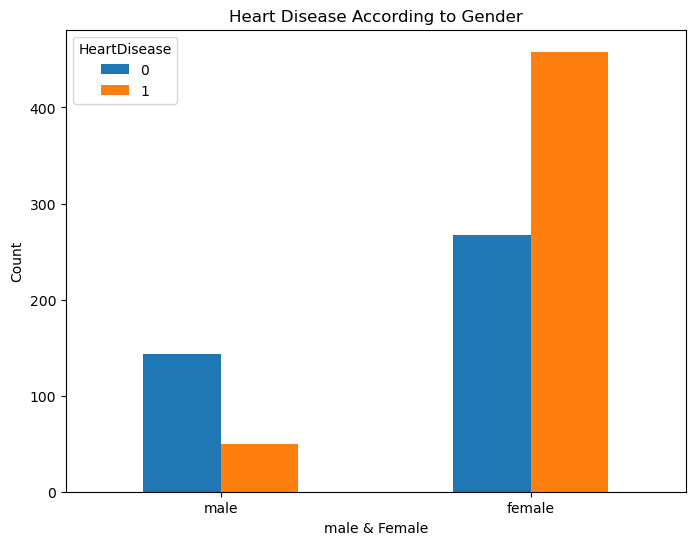

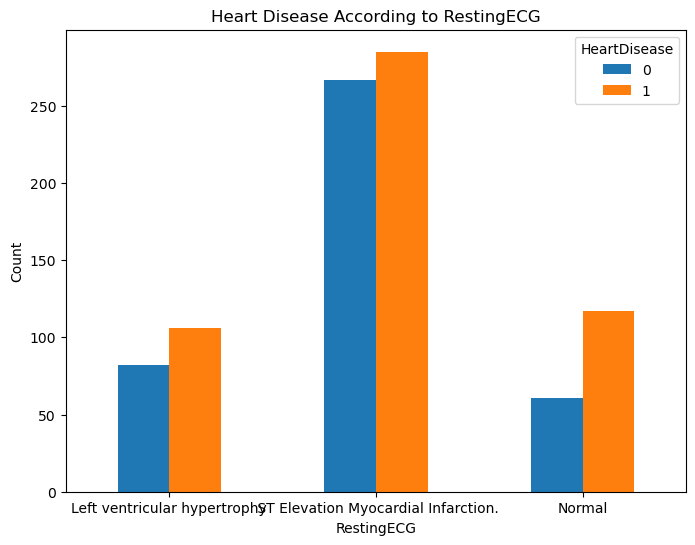

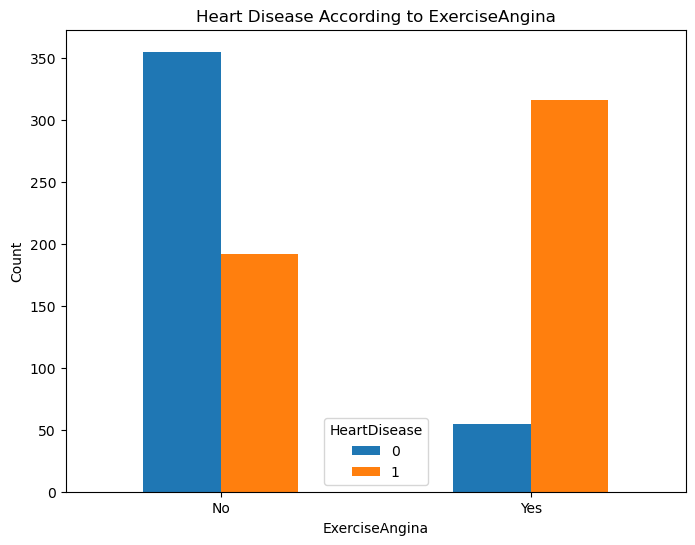

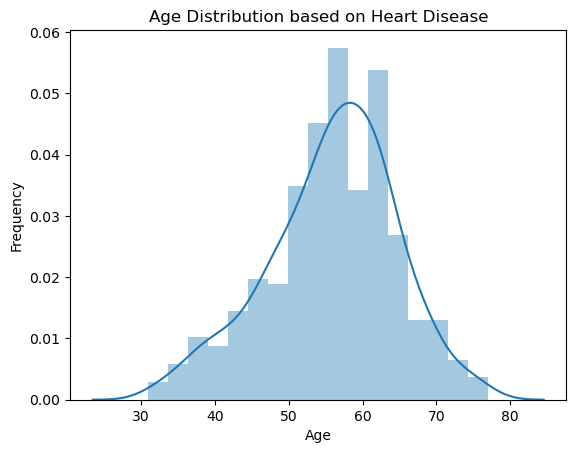


3.After Data Preprocessing:

   Age  Sex  ChestPainType  RestingBP  Cholesterol  FastingBS  RestingECG  \
0   40    1              1        140          289          0           1   
1   49    0              2        160          180          0           1   
2   37    1              1        130          283          0           2   
3   48    0              0        138          214          0           1   
4   54    1              2        150          195          0           1   

   MaxHR  ExerciseAngina  Oldpeak  ST_Slope  HeartDisease  
0    172               0      0.0         2             0  
1    156               0      1.0         1             1  
2     98               0      0.0         2             0  
3    108               1      1.5         1             1  
4    122               0      0.0         2             0  


4.Accuracy:

Naive Bayes Accuracy is 0.8586956521739131


5.Prediction Output:

The Patient is Normal


In [1]:
# Importing required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score
import warnings
warnings.filterwarnings('ignore')

# Reading csv
df=pd.read_csv('heart.csv')
print("1.Before Preprocessing:\n")
print(df.head())

# Printing Title Statement
print("\n\n2.Visualization:\n")

# Percentage of the positive and negative heart disease
labels = ['Yes', 'No']
values = df['HeartDisease'].value_counts().values
plt.pie(values, labels=labels, autopct='%1.0f%%')
plt.title('HeartDisease')
plt.show()

print("\n")

# Chest pain types based on the Heart Disease
pd.crosstab(df.ChestPainType,df.HeartDisease).plot(kind = "bar", figsize = (8, 6))
plt.title('Heart Disease Frequency According to Chest Pain Type')
plt.xlabel('Chest Pain Type')
plt.xticks(np.arange(4), ('typical angina', 'atypical angina', 'non-anginal pain', 'asymptomatic'), rotation = 0)
plt.ylabel('Frequency')
plt.show()

print("\n")

# Heart Disease According to Gender
pd.crosstab(df.Sex,df.HeartDisease).plot(kind = "bar", figsize = (8, 6))
plt.title('Heart Disease According to Gender')
plt.xlabel('male & Female')
plt.xticks(np.arange(2), ('male', 'female'), rotation = 0)
plt.ylabel('Count')
plt.show()

print("\n")

# Heart Disease According to RestingECG
pd.crosstab(df.RestingECG,df.HeartDisease).plot(kind = "bar", figsize = (8, 6))
plt.title('Heart Disease According to RestingECG')
plt.xlabel('RestingECG')
plt.xticks(np.arange(3), ('Left ventricular hypertrophy', ' ST Elevation Myocardial Infarction.', 'Normal'), rotation = 0)
plt.ylabel('Count')
plt.show()

print("\n")

# Heart Disease According to ExerciseAngina
pd.crosstab(df.ExerciseAngina,df.HeartDisease).plot(kind = "bar", figsize = (8, 6))
plt.title('Heart Disease According to ExerciseAngina')
plt.xlabel('ExerciseAngina')
plt.xticks(np.arange(2), ( 'No','Yes'), rotation = 0)
plt.ylabel('Count')
plt.show()

print("\n")

# Age distribution based on heart disease
sns.distplot(df[df['HeartDisease'] == 1]['Age'], label='Have heart disease')
sns.distplot(df[df['HeartDisease'] == 2]['Age'], label = 'Do not have heart disease')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.title('Age Distribution based on Heart Disease')
plt.show()

# Data Preprocessing

le=LabelEncoder()

df['Sex'] = le.fit_transform(df['Sex'])
df['ChestPainType'] = le.fit_transform(df['ChestPainType'])
df['RestingECG'] = le.fit_transform(df['RestingECG'])
df['ExerciseAngina'] = le.fit_transform(df['ExerciseAngina'])
df['ST_Slope'] = le.fit_transform(df['ST_Slope'])


# Printing Statement
print("\n3.After Data Preprocessing:\n")
print(df.head(5))

# Assigning variable
x=df.drop(columns=['HeartDisease'])
y=df['HeartDisease']     


# Splitting values
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=4)  

# Fitting Model to train data
NB = GaussianNB()
NB.fit(x_train, y_train)

# Predicting 
y_pred=NB.predict(x_test)


# Printing Accuracy
print("\n\n4.Accuracy:\n")
print('Naive Bayes Accuracy is', accuracy_score(y_test,y_pred))

print("\n")

import pickle
pickle.dump(NB,open('model.pkl','wb'))

# Testing the prediction
print("5.Prediction Output:\n")
testPrediction = NB.predict([[19,1,4,120,166,0,1,138,0,0,2]])
if testPrediction==1:
    print("The Patient Have Heart Disease,please consult the Doctor")
else:
    print("The Patient is Normal")